In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

df=pd.read_csv("/content/q3_retail_promotions.csv")
df["transaction_date"]=pd.to_datetime(df["transaction_date"])

df["year"]=df["transaction_date"].dt.year
df["month"]=df["transaction_date"].dt.month
df["day_of_week"]=df["transaction_date"].dt.dayofweek
df["is_month_end"]=(df["transaction_date"].dt.day >=25).astype(int)
print(df.head())


  transaction_date  store_id store_size  ... month day_of_week  is_month_end
0       2022-01-01        28      small  ...     1           5             0
1       2022-01-01         5     medium  ...     1           5             0
2       2022-01-02        13      small  ...     1           6             0
3       2022-01-02        17      small  ...     1           6             0
4       2022-01-03        50     medium  ...     1           0             0

[5 rows x 13 columns]


In [5]:
df=df.sort_values(by="transaction_date")
split_index=int(len(df)*0.8)
train_df=df.iloc[:split_index]
test_df=df.iloc[split_index:]
X_train=train_df.drop(columns=["items_sold","transaction_date"])
y_train=train_df["items_sold"]
X_test=test_df.drop(columns=["items_sold","transaction_date"])
y_test=test_df["items_sold"]

In time-series or time-dependent data, future values depend on past patterns. A random split would mix future data into training, causing data leakage.This leads to unrealistically high  performance.

Temporal split ensures:
1. Model trains only on past data
2. Model is tested on unseen future data
3. Mimics real-world prediction scenario

In [7]:
categorical_features = ["promotion_type", "location_type", "store_size"]
numerical_features = [
    "store_id", "is_weekend", "is_festival",
    "competition_density", "year", "month",
    "day_of_week", "is_month_end"
]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)


Linear Regression Performance:
RMSE: 27.12
MAE: 21.05
------------------------------
Random Forest Performance:
RMSE: 30.82
MAE: 24.14
------------------------------


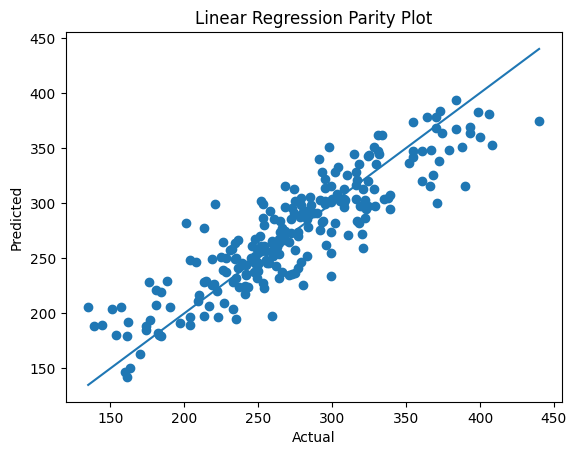

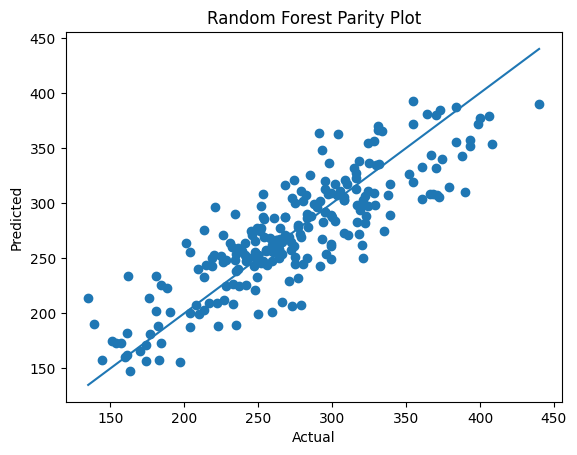

Top 5 Important Features:
                feature  importance
10     store_size_small    0.173360
13          is_festival    0.173027
7   location_type_urban    0.111915
17          day_of_week    0.086417
12           is_weekend    0.063369


In [8]:
# Linear Regression
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

# Random Forest Regressor
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{model_name} Performance:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print("-" * 30)
evaluate_model(y_test, lr_preds, "Linear Regression")
evaluate_model(y_test, rf_preds, "Random Forest")
def parity_plot(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

parity_plot(y_test, lr_preds, "Linear Regression Parity Plot")
parity_plot(y_test, rf_preds, "Random Forest Parity Plot")
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_features = list(encoded_cat_features) + numerical_features

# Get importances
importances = rf_pipeline.named_steps["model"].feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)
# Top 5 features
print("Top 5 Important Features:")
print(feature_importance_df.head(5))